
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
dx,dy = 0.1, 0.1 #mm. Separación de cada casilla
a,b = 20, 10 #mm
ny,nx = int(b/dy), int(a/dx) #tamaño de la matriz
placa = np.zeros((ny,nx),float)
D=84


def difusion(uo,dt,dx,D):
  uo[1:-1,1:-1] = uo[1:-1,1:-1]+dt*D*(uo[2:,1:-1]+uo[:-2,1:-1]+uo[1:-1,2:]+uo[1:-1,:-2]-4*uo[1:-1,1:-1])/dx**2
  uo = uo.copy()
  return uo

f = lambda x: 100*np.sin(3*np.pi*x/a)
condiciones = placa
for i in range(nx):
  condiciones[-1,i] = f(i*dx)
dt = dx**2*dy**2/(2*D*(dx**2 + dy**2))
tiempo = 1000
for i in range(1,tiempo):
  condiciones = difusion(condiciones,dt,dx,D)


#Solucion analitica

In [4]:
from scipy.integrate import quad
Ny, Nx = 100, 200

x = np.linspace(0, a, Nx)
y = np.linspace(0, b, Ny)
X, Y = np.meshgrid(x, y)

def calcular_coeficiente_Cn(n, a, b, func_f):
    integrand = lambda x: func_f(x)*np.sin(n*np.pi*x/a)
    integral, _ = quad(integrand,0,a)

    coef = (2 / a) * (1 / np.sinh(n * np.pi * b / a)) * integral
    return coef
N_terms = 50
T = np.zeros((Ny,Nx),float)

for n in range(1, N_terms + 1):
    cn = calcular_coeficiente_Cn(n, a, b, f)
    term = cn * np.sin(n * np.pi * X / a) * np.sinh(n * np.pi * Y / a)
    T += term

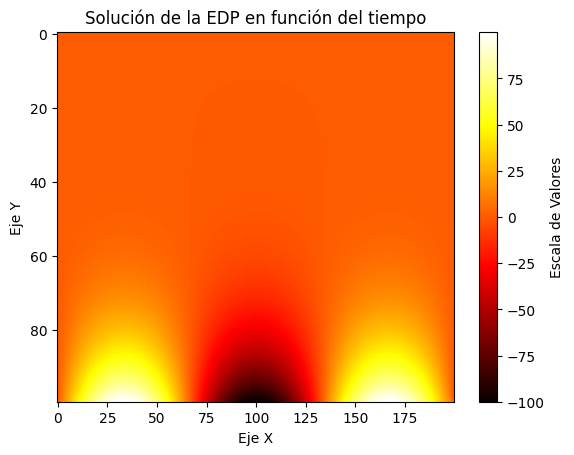

In [5]:
fig = figsize=(14, 6)

mapa1 = plt.imshow(condiciones, cmap='hot', aspect='auto')
plt.colorbar(mapa1, label='Escala de Valores')
plt.title("Solución de la EDP en función del tiempo")
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.show()

In [6]:
def laplace(uo):
  uo[1:-1,1:-1] = (1/4)*(uo[2:,1:-1]+uo[:-2,1:-1]+uo[1:-1,2:]+uo[1:-1,:-2])
  return uo
dx,dy = 0.1, 0.1 #mm. Separación de cada casilla
a,b = 20, 10 #mm
ny,nx = int(b/dy)+1, int(a/dx)+1 #tamaño de la matriz
placa = np.zeros((ny,nx),float)


f = lambda x: 100*np.sin(3*np.pi*x/a)
condiciones1 = placa
for i in range(nx):
  condiciones1[-1,i] = f(i*dx)
dt = dx**2*dy**2/(2*D*(dx**2 + dy**2))
tol = 1
while tol>=10**(-3):
  conolb = condiciones1.copy()
  condiciones1 = laplace(condiciones1)
  tol = np.max(np.abs(conolb-condiciones1))
condiciones1



array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.49379490e-03, 4.98205295e-03, ...,
        4.98205295e-03, 2.49379490e-03, 0.00000000e+00],
       [0.00000000e+00, 4.99714484e-03, 9.98319476e-03, ...,
        9.98319476e-03, 4.99714484e-03, 0.00000000e+00],
       ...,
       [0.00000000e+00, 4.28284729e+00, 8.55618560e+00, ...,
        8.55618560e+00, 4.28284729e+00, 0.00000000e+00],
       [0.00000000e+00, 4.49175604e+00, 8.97353926e+00, ...,
        8.97353926e+00, 4.49175604e+00, 0.00000000e+00],
       [0.00000000e+00, 4.71064507e+00, 9.41083133e+00, ...,
        9.41083133e+00, 4.71064507e+00, 3.67394040e-14]])

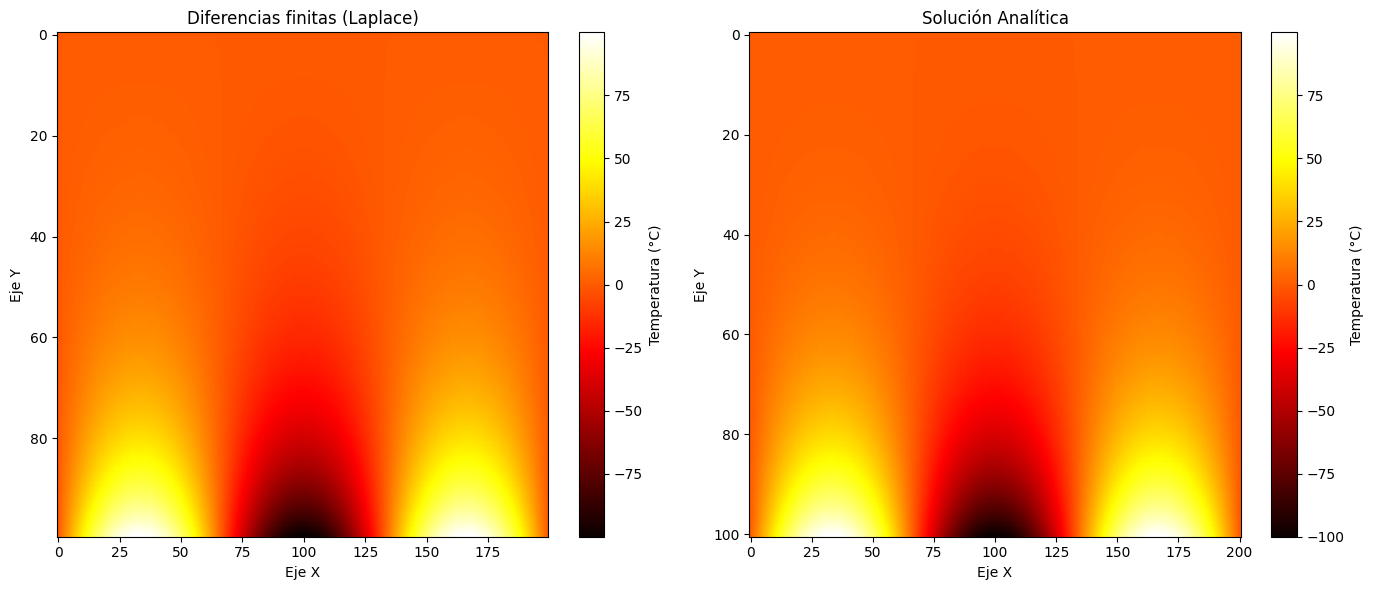

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
mapa1 = ax1.imshow(T, cmap='hot', aspect='auto')
fig.colorbar(mapa1, ax=ax1, label='Temperatura (°C)')
ax1.set_title('Diferencias finitas (Laplace)')
ax1.set_xlabel('Eje X')
ax1.set_ylabel('Eje Y')

mapa2 = ax2.imshow(condiciones1, cmap='hot', aspect='auto')
fig.colorbar(mapa2, ax=ax2, label='Temperatura (°C)')
ax2.set_title('Solución Analítica')
ax2.set_xlabel('Eje X')
ax2.set_ylabel('Eje Y')

plt.tight_layout()
plt.show()